In [2]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 4.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 1.4 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 7.5 MB/s  0:00:00 eta 0:00:01m
  Attempting uninstall: dill
    Found existing installation: dill 0.4.0
    Uninstalling dill-0.4.0:
      Successfully uninstalled dill-0.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [datasets]5/6 [datasets]ce-hub]


In [3]:
from datasets import load_dataset

ds = load_dataset("polinaeterna/amazon_apparel_copy")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005-42ff0d1da8db31(…):   0%|          | 0.00/181M [00:00<?, ?B/s]

data/train-00001-of-00005-96538f337144f5(…):   0%|          | 0.00/185M [00:00<?, ?B/s]

data/train-00002-of-00005-cea76d6b387a05(…):   0%|          | 0.00/205M [00:00<?, ?B/s]

data/train-00003-of-00005-0f3826be47a1cb(…):   0%|          | 0.00/221M [00:00<?, ?B/s]

data/train-00004-of-00005-48ed3e888c3fe9(…):   0%|          | 0.00/236M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5906333 [00:00<?, ? examples/s]

In [6]:
print(ds)
print(ds.keys())
print(ds['train'])
print(ds['train'].column_names)

DatasetDict({
    train: Dataset({
        features: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date'],
        num_rows: 5906333
    })
})
dict_keys(['train'])
Dataset({
    features: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date'],
    num_rows: 5906333
})
['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date']


In [9]:
import pandas as pd
df = ds['train'].to_pandas()

In [12]:
print(df['star_rating'].describe())

count    5.906333e+06
mean     4.105229e+00
std      1.259279e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: star_rating, dtype: float64


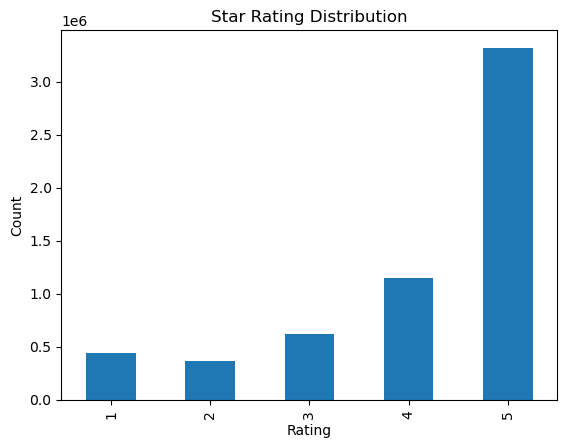

In [13]:
import matplotlib.pyplot as plt

df['star_rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Star Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [14]:
missing = df.isnull().sum()
missing_ratio = df.isnull().mean()

quality = pd.DataFrame({
    "missing_count": missing,
    "missing_ratio": missing_ratio
})

print(quality.sort_values(by="missing_ratio", ascending=False))

                   missing_count  missing_ratio
marketplace                    0            0.0
customer_id                    0            0.0
review_id                      0            0.0
product_id                     0            0.0
product_parent                 0            0.0
product_title                  0            0.0
product_category               0            0.0
star_rating                    0            0.0
helpful_votes                  0            0.0
total_votes                    0            0.0
vine                           0            0.0
verified_purchase              0            0.0
review_headline                0            0.0
review_body                    0            0.0
review_date                    0            0.0


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
invalid_votes = df[df['helpful_votes'] > df['total_votes']]
print("Invalid vote rows:", len(invalid_votes))

Invalid vote rows: 0


In [17]:
df['review_length'] = df['review_body'].astype(str).apply(len)

print(df['review_length'].describe())

count    5.906333e+06
mean     1.787897e+02
std      2.260695e+02
min      0.000000e+00
25%      5.100000e+01
50%      1.220000e+02
75%      2.200000e+02
max      3.054000e+04
Name: review_length, dtype: float64


In [18]:
empty_reviews = (df['review_length'] == 0).sum()
print("Empty reviews:", empty_reviews)

Empty reviews: 776


In [19]:
print(df.groupby('verified_purchase')['star_rating'].mean())

verified_purchase
0    3.987130
1    4.118423
Name: star_rating, dtype: float64


In [20]:
print(df.groupby('star_rating')['review_length'].mean())

star_rating
1    202.245487
2    211.068260
3    203.648362
4    196.107926
5    161.399458
Name: review_length, dtype: float64
